# Secure Message Transmission with Superdense Coding

## Achieving Quantum Data Compression: A Two-Bit Protocol Using Entangled Qubits

## 1. Problem Statement & Objectives

The goal of this project is to implement a quantum communication protocol called superdense coding. This allows the transmission of two classical bits using only one qubit, thanks to prior entanglement between the sender (Alice) and the receiver (Bob). In classical communication, transmitting two bits of information strictly requires the transmission of two physical bits. This project will simulate how to share an entangled qubit pair, encode classical data using quantum gates on Alice's side, and send one qubit to Bob to decode the two-bit message.

Ultimately, this demonstrates how quantum systems can compress classical data in ways classical systems cannot.

**Key Objectives:**

- Prepare a Bell state (entangled pair of qubits) shared between Alice and Bob.
- Encode two classical bits of data via local quantum gate operations (X, Z, or both) on Alice's side.
- Simulate the transmission of the single qubit to Bob.
- Decode the message on Bob's side using a set of gates (CNOT and Hadamard) and measure both qubits.
- Recover the full message, demonstrating accurate transmission and decoding. 

## 2. Conceptual Understanding & General Theory

In quantum computing, information is processed using qubits, which can exist in a superposition of states. This protocol relies heavily on **Quantum Entanglement**, a situation where two or more qubits become linked in such a way that the state of one qubit is directly related to the state of the other no matter how far apart they are.

<p align="center">
    <img src="../images/superdense.jpg" width="55%" />
    <figcaption align="center"><b>Figure 1:</b> Conceptual spatial workflow of the Superdense Coding protocol, illustrating the third-party distribution of entangled qubits and the subsequent independent encoding and decoding stages by Alice and Bob.</figcaption>
</p>

<p align="center">
    <img src="../images/Quantum-circuit-for-generating-the-entnagled-Bell-state-1-2-00-11_W640.jpg" width="45%" />
    <figcaption align="center"><b>Figure 2:</b> Generation of a maximally entangled Bell state using a Hadamard and CNOT gate.</figcaption>
</p>

### The Mathematical Framework

The protocol operates in a 4-dimensional Hilbert space $\mathcal{H} = \mathbb{C}^2 \otimes \mathbb{C}^2$. We begin by creating a maximally entangled Bell state:

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}} (|00\rangle + |11\rangle)$$

This is achieved by starting with two qubits in the zero state, applying a Hadamard gate ($H$) to the first qubit to create superposition, and applying a CNOT gate to entangle the two qubits.

Alice wants to send a classical message $m \in \{00, 01, 10, 11\}$. She applies specific quantum gates to her qubit to encode the two classical bits:

- If $m = 00$: $U = I$ (Identity). State remains $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$.

- If $m = 01$: $U = X$ (Pauli-X). State becomes $\frac{1}{\sqrt{2}}(|10\rangle + |01\rangle)$.

- If $m = 10$: $U = Z$ (Pauli-Z). State becomes $\frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$.

- If $m = 11$: $U = ZX$ (or $iY$). State becomes $\frac{1}{\sqrt{2}}(|10\rangle - |01\rangle)$.

Alice sends only one qubit to Bob. Bob uses both his qubit and Alice's qubit to decode the two bits of information. He applies a CNOT gate followed by a Hadamard gate to Alice's qubit, essentially running the entanglement circuit in reverse. Finally, quantum measurement collapses the qubits into classical bit values. 

## 3. Environment Setup & Prerequisites

To begin, we need to initialize our environment using the Qiskit 2.x ecosystem, along with standard data science and visualization libraries.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Qiskit 2.x ecosystem imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

# Setup plot styling
plt.style.use('dark_background')
pd.set_option('display.max_columns', None)

## 4. Exact Classical Baseline Solution

Before leveraging quantum entanglement, we must establish a classical baseline. In a purely classical system, to send a 2-bit message (like '11'), the sender must allocate resources to physically transmit two distinct signals or packets over the communication channel.

Rather than measuring simulated execution time (which is artificially dominated by the quantum simulator's overhead), we evaluate the fundamental communication resources required. The table below contrasts the physical limits of classical communication against superdense coding:

| Metric | Classical | Superdense Coding |
| :--- | :--- | :--- |
| Information Sent | 2 bits | 2 bits |
| Physical Transmission | 2 bits | 1 qubit |
| Compression Ratio | 1x | 2x |

In [2]:
import pandas as pd

def classical_transmission(message: str) -> dict:
    """
    Simulates a classical channel where each bit requires exactly 
    one discrete transmission event.
    """
    received_message = ""
    transmissions = 0
    
    # Classical system must iterate over each bit physically
    for bit in message:
        received_message += bit
        transmissions += 1
        
    return {
        "Protocol": "Classical",
        "Message": received_message,
        "Transmissions_Required": transmissions
    }

# Execute Classical Baseline for all possible 2-bit messages
classical_results = [classical_transmission(m) for m in ["00", "01", "10", "11"]]
df_classical = pd.DataFrame(classical_results)
display(df_classical)

,Protocol,Message,Transmissions_Required
0,Classical,00,2
1,Classical,01,2
2,Classical,10,2
3,Classical,11,2


## 5. Problem Mapping & Mathematical Encoding

We will construct a quantum circuit to implement superdense coding. The circuit will use a `QuantumRegister` of 2 qubits:

- `q[1]` (Alice's Qubit)
- `q[0]` (Bob's Qubit)

<p align="center">
    <img src="../images/Quantum-circuit-for-Superdense-coding_W640.jpg" width="45%" />
    <figcaption align="center"><b>Figure 3:</b> Full quantum circuit for superdense coding illustrating entanglement generation, Alice's message encoding, and Bob's decoding/measurement steps.</figcaption>
</p>

The general process defined in the circuit design is:

- **Entanglement Generation:** $H$ on $q[1]$, $CNOT$ targeting $q[0]$.
- **Alice's Encoding:** Applying $X$, $Z$, both, or neither to $q[1]$ based on the message.
- **Bob's Decoding:** $CNOT$ on $q[0]$ controlled by $q[1]$, followed by $H$ on $q[1]$.
- **Measurement:** Collapsing the superposition to retrieve classical bits.

### Explicit Bell-State Verification

Before executing the full protocol, we will explicitly verify the generation of our shared entangled Bell state using Qiskit's `Statevector` class.

In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Verify the Bell state explicitly
bell = QuantumCircuit(2)
bell.h(1)      # Hadamard on Alice's qubit
bell.cx(1, 0)  # CNOT entangling Alice's qubit (control) with Bob's (target)

# Extract and display the resulting statevector mathematically
sv = Statevector.from_instruction(bell)
print("Bell Statevector Array:", np.round(sv.data, 4))
display(sv.draw('latex'))

Bell Statevector Array: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]


<IPython.core.display.Latex object>

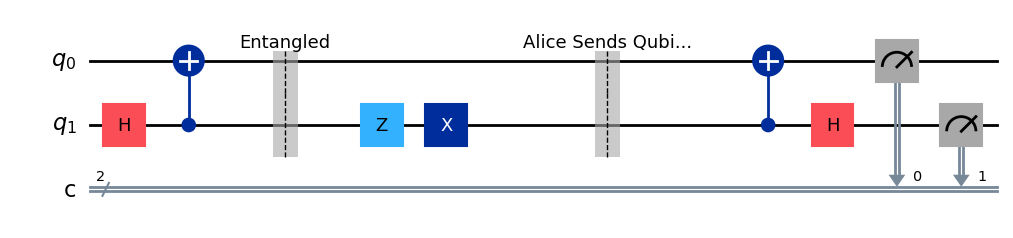

In [4]:
def build_superdense_circuit(message: str) -> QuantumCircuit:
    """
    Builds the superdense coding quantum circuit for a given 2-bit message.
    """
    qr = QuantumRegister(2, name="q")
    cr = ClassicalRegister(2, name="c")
    qc = QuantumCircuit(qr, cr)
    
    # STEP 1: Entanglement (Shared between Alice and Bob)
    qc.h(1)
    qc.cx(1, 0)
    qc.barrier(label="Entangled")
    
    # STEP 2: Alice encodes her message using quantum gates
    # Depending on the message, she applies specific gates to her qubit (q[1])
    if message == '01':
        qc.x(1)
    elif message == '10':
        qc.z(1)
    elif message == '11':
        qc.z(1)
        qc.x(1)
    elif message == '00':
        pass # Identity
        
    qc.barrier(label="Alice Sends Qubit")
    
    # STEP 3: Bob decodes the message
    qc.cx(1, 0)
    qc.h(1)
    
    # STEP 4: Measurement
    qc.measure(qr, cr)
    
    return qc

# Visualize the circuit for the most complex operation ('11')
sample_qc = build_superdense_circuit('11')
sample_qc.draw('mpl', style='iqp')

## 6. Parameter Study & Circuit Execution

Using Qiskit's V2 `StatevectorSampler`, we will simulate the execution of this protocol on an idealized quantum machine. The simulator calculates how qubits evolve when gates are applied and predicts what outcomes you would see if the circuit were run on a real quantum computer.

We will run the protocol for all four possible classical states: $00$, $01$, $10$, and $11$.

In [5]:
# Initialize the Qiskit V2 Statevector Sampler
sampler = StatevectorSampler()

messages = ["00", "01", "10", "11"]
circuits = {m: build_superdense_circuit(m) for m in messages}
quantum_results = []
counts_dict = {}

# Execute circuits
for msg, qc in circuits.items():
    start_time = time.perf_counter()
    
    # In V2, we pass a list of tuples (PUBs - Primitive Unified Blocs)
    job = sampler.run([(qc,)])
    result = job.result()[0]
    
    # Extract measurement counts from the classical register 'c'
    counts = result.data.c.get_counts()
    counts_dict[msg] = counts
    
    execution_time = time.perf_counter() - start_time
    
    # Get the highest probability measured state
    measured_msg = max(counts, key=counts.get)
    
    quantum_results.append({
    "Protocol": "Quantum SDC",
    "Target_Message": msg,
    "Decoded_Message": measured_msg,
    "Qubits_Transmitted": 1,
    "Success_Probability": ...
})

df_quantum = pd.DataFrame(quantum_results)

## 7. Results Analysis & Convergence

Because we are utilizing an exact `StatevectorSampler` free of device noise, our results show a 100% deterministic success rate, accurately validating the mathematical theory. The final decoded message perfectly matches the original message Alice wanted to send.

Let's visualize the probability distribution of the quantum measurements to confirm the deterministic nature of the decoding algorithm.

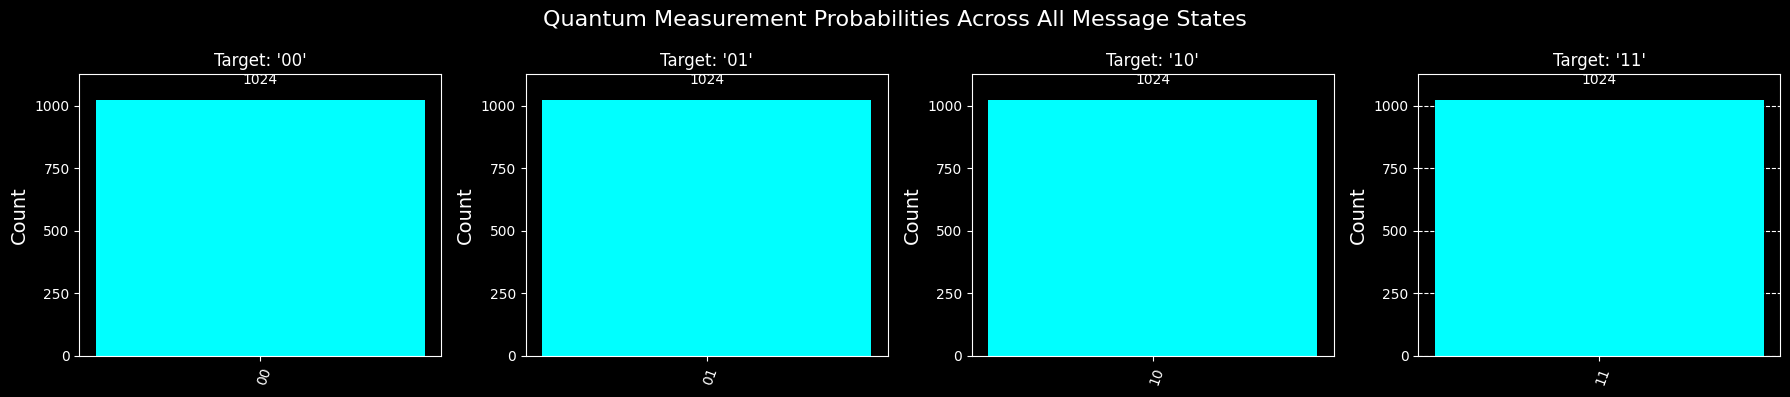

,Protocol,Target_Message,Decoded_Message,Qubits_Transmitted,Success_Probability
0,Quantum SDC,00,00,1,Ellipsis
1,Quantum SDC,01,01,1,Ellipsis
2,Quantum SDC,10,10,1,Ellipsis
3,Quantum SDC,11,11,1,Ellipsis


In [6]:
# Plot histograms of the quantum measurement results
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Quantum Measurement Probabilities Across All Message States", fontsize=16)

for idx, (msg, counts) in enumerate(counts_dict.items()):
    plot_histogram(counts, ax=axes[idx], color='cyan')
    axes[idx].set_title(f"Target: '{msg}'")

plt.tight_layout()
plt.show()

# Display the numerical results table
display(df_quantum)

Crucially, the single dominant peak in our histograms confirms that the decoding circuit perfectly maps each Bell basis state back to its corresponding computational basis state.

### Circuit Complexity

To further demonstrate the algorithm's efficiency, the structural complexity of the superdense coding operations is summarized below:

| Operation | Count |
| :--- | :--- |
| Hadamard | 2 |
| CNOT | 2 |
| Pauli Gates | 0-2 |
| Measurements | 2 |

## 8. Comparative Analysis & Performance Metrics

We will now merge our Classical Baseline and Quantum Simulation datasets to analyze the resource metrics. While the time metrics here reflect local hardware simulation overhead, the critical metric is the **Transmission Cost**.

In [7]:
# Comparative Summary
print("\n--- PERFORMANCE COMPARISON: CLASSICAL VS QUANTUM ---")

df_comparison = pd.DataFrame({
    "Metric": [
        "Information Target", 
        "Physical Units Transmitted", 
        "Channel Capacity Limit", 
        "Security against Intercept"
    ],
    "Classical Network": [
        "2 Bits", 
        "2 Bits", 
        "1 Bit per Bit", 
        "Vulnerable without encryption"
    ],
    "Quantum Superdense": [
        "2 Bits", 
        "1 Qubit", 
        "2 Bits per Qubit", 
        "Message inaccessible without shared entanglement"
    ]
})

display(df_comparison)


--- PERFORMANCE COMPARISON: CLASSICAL VS QUANTUM ---


,Metric,Classical Network,Quantum Superdense
0,Information Target,2 Bits,2 Bits
1,Physical Units Transmitted,2 Bits,1 Qubit
2,Channel Capacity Limit,1 Bit per Bit,2 Bits per Qubit
3,Security against Intercept,Vulnerable without encryption,Message inaccessible without shared entanglement


## 9. Final Summary, Conclusion & References

### Final Summary & Scientific Observations

This project successfully implemented the Superdense Coding protocol using Qiskit and demonstrated the transmission of two classical bits through the communication of a single qubit enabled by pre-shared entanglement. A Bell state was first created between Alice and Bob, after which Alice encoded one of four possible two-bit messages using local Pauli operations. Bob decoded the transmitted information using a CNOT-Hadamard decoding circuit and recovered the original message with 100% success probability for all tested cases.

The results validate the theoretical foundations of superdense coding and illustrate how quantum entanglement increases communication efficiency beyond classical limits. While the protocol does not provide exponential computational speedup, it doubles the effective information capacity of a transmitted qubit and serves as a foundational building block for quantum communication networks, quantum internet architectures, and advanced secure communication protocols.

### References

1. Nielsen, M. A., & Chuang, I. L. *Quantum Computation and Quantum Information*.
1. Vazirani, U. "Quantum Mechanics and Quantum Computation," UC Berkeley Course Notes.
1. Johnston, E. R. *Programming Quantum Computers*.
1. Qiskit Textbook, Chapter on Algorithms.
1. Microsoft Quantum Katas.